In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.linear_model import LogisticRegression

In [5]:
from sklearn.pipeline import make_pipeline

In [6]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [7]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [8]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [9]:
print(df.shape)

(7043, 21)


In [10]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [12]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [13]:
print(df["TotalCharges"].head())

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str


In [14]:
print(df["TotalCharges"].str.strip().eq("").sum())

11


In [15]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [16]:
print(df["TotalCharges"].isnull().sum())

11


In [17]:
df = df.dropna(subset=["TotalCharges"])

In [18]:
print(df.shape)
print(df["TotalCharges"].isnull().sum())

(7032, 21)
0


In [19]:
print(df["Churn"].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [20]:
print(df["Churn"].value_counts(normalize=True))

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


In [21]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [22]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (7032, 19)
y shape: (7032,)
Churn
0    5163
1    1869
Name: count, dtype: int64


In [23]:
print(X.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [25]:
numeric_features = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [28]:
model = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000)
)

In [29]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [30]:
probabilities = model.predict_proba(X_test)

In [31]:
print(probabilities[:5])

[[0.98248697 0.01751303]
 [0.40807869 0.59192131]
 [0.99517897 0.00482103]
 [0.79834833 0.20165167]
 [0.8984986  0.1015014 ]]


In [32]:
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [33]:
probabilities[:, 1]

array([0.01751303, 0.59192131, 0.00482103, ..., 0.13098875, 0.02525535,
       0.00444712], shape=(1407,))

In [34]:
print("Training size:", len(y_train))
print("Testing size:", len(y_test))

print("\nTraining proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training size: 5625
Testing size: 1407

Training proportions:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing proportions:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [35]:
model.fit(X_train, y_train)

probabilities = model.predict_proba(X_test)

print(probabilities[:5])

[[0.98248697 0.01751303]
 [0.40807869 0.59192131]
 [0.99517897 0.00482103]
 [0.79834833 0.20165167]
 [0.8984986  0.1015014 ]]


In [36]:
results = pd.DataFrame({
    "Actual_class": y_test.values,
    "P_no_churn": probabilities[:, 0],
    "P_churn": probabilities[:, 1]
})

print(results.head(10))

   Actual_class  P_no_churn   P_churn
0             0    0.982487  0.017513
1             0    0.408079  0.591921
2             0    0.995179  0.004821
3             1    0.798348  0.201652
4             0    0.898499  0.101501
5             1    0.528155  0.471845
6             0    0.973482  0.026518
7             0    0.834569  0.165431
8             1    0.320400  0.679600
9             0    0.984475  0.015525


In [37]:
threshold = 0.50

In [38]:
results["Predicted_churn"] = (
    results["P_churn"] >= threshold
).astype(int)

In [39]:
print(
    results[
        ["Actual_class", "P_churn", "Predicted_churn"]
    ].head(10)
)

   Actual_class   P_churn  Predicted_churn
0             0  0.017513                0
1             0  0.591921                1
2             0  0.004821                0
3             1  0.201652                0
4             0  0.101501                0
5             1  0.471845                0
6             0  0.026518                0
7             0  0.165431                0
8             1  0.679600                1
9             0  0.015525                0


In [40]:
thresholds = [0.10, 0.30, 0.50, 0.70, 0.90]

metric_results = []

In [41]:
for threshold in thresholds:

    y_pred_threshold = (
        probabilities[:, 1] >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold,
        labels=[0, 1]
    ).ravel()

    accuracy = (
        (tp + tn) /
        (tp + tn + fp + fn)
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    sensitivity_recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    f1_score = (
        2 * precision * sensitivity_recall /
        (precision + sensitivity_recall)
        if (precision + sensitivity_recall) > 0
        else 0
    )

    metric_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity_Recall": sensitivity_recall,
        "Specificity": specificity,
        "F1_Score": f1_score
    })

In [42]:
threshold_metrics = pd.DataFrame(metric_results)

display(threshold_metrics.round(3))

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Sensitivity_Recall,Specificity,F1_Score
0,0.1,499,534,20,354,0.606,0.399,0.947,0.483,0.561
1,0.3,761,272,90,284,0.743,0.511,0.759,0.737,0.611
2,0.5,917,116,160,214,0.804,0.648,0.572,0.888,0.608
3,0.7,1013,20,311,63,0.765,0.759,0.168,0.981,0.276
4,0.9,1033,0,374,0,0.734,0.000,0.000,1.000,0.000


In [43]:
best_f1_row = threshold_metrics.loc[
    threshold_metrics["F1_Score"].idxmax()
]

print("Best threshold based on F1 Score:")
print(best_f1_row)

Best threshold based on F1 Score:
Threshold               0.300000
TN                    761.000000
FP                    272.000000
FN                     90.000000
TP                    284.000000
Accuracy                0.742715
Precision               0.510791
Sensitivity_Recall      0.759358
Specificity             0.736689
F1_Score                0.610753
Name: 1, dtype: float64


In [44]:
best_recall_row = threshold_metrics.loc[
    threshold_metrics["Sensitivity_Recall"].idxmax()
]

print("Best threshold based on Recall:")
print(best_recall_row)

Best threshold based on Recall:
Threshold               0.100000
TN                    499.000000
FP                    534.000000
FN                     20.000000
TP                    354.000000
Accuracy                0.606254
Precision               0.398649
Sensitivity_Recall      0.946524
Specificity             0.483059
F1_Score                0.561014
Name: 0, dtype: float64


In [45]:
best_precision = threshold_metrics.loc[
    threshold_metrics["Precision"].idxmax()
]

print("Best threshold based on Precision:")
print(best_precision)

Best threshold based on Precision:
Threshold                0.700000
TN                    1013.000000
FP                      20.000000
FN                     311.000000
TP                      63.000000
Accuracy                 0.764748
Precision                0.759036
Sensitivity_Recall       0.168449
Specificity              0.980639
F1_Score                 0.275711
Name: 3, dtype: float64


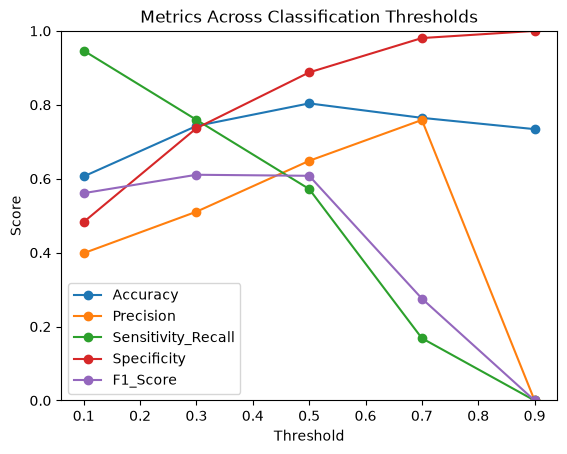

In [46]:
threshold_metrics.plot(
    x="Threshold",
    y=[
        "Accuracy",
        "Precision",
        "Sensitivity_Recall",
        "Specificity",
        "F1_Score"
    ],
    marker="o"
)

plt.title("Metrics Across Classification Thresholds")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

In [47]:
from imblearn.over_sampling import SMOTE

ModuleNotFoundError: No module named 'imblearn'

In [48]:
!pip install imbalanced-learn

   ---------------------------------------- 0.0/236.1 kB ? eta -:--:--
   ----------------- ---------------------- 102.4/236.1 kB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 236.1/236.1 kB 3.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
from imblearn.over_sampling import SMOTE

In [50]:
print("Before SMOTE:")
print(y.value_counts())
print(y.value_counts(normalize=True))

Before SMOTE:
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [54]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [55]:
smote = SMOTE(
    sampling_strategy=0.05,
    random_state=42
)

In [56]:
target_minority = int(y_train.value_counts()[1] * 1.05)

In [57]:
minority_count = y_train.value_counts()[1]
majority_count = y_train.value_counts()[0]

target_minority = int(minority_count * 1.05)

sampling_strategy = target_minority / majority_count

print("Original minority count:", minority_count)
print("Target minority count:", target_minority)
print("Sampling strategy:", sampling_strategy)

Original minority count: 1495
Target minority count: 1569
Sampling strategy: 0.37990314769975786


In [58]:
smote = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [59]:
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Churn
0    4130
1    1569
Name: count, dtype: int64


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
Churn
0    4130
1    1495
Name: count, dtype: int64

Testing class distribution:
Churn
0    1033
1     374
Name: count, dtype: int64


In [61]:
from sklearn.linear_model import LogisticRegression

smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [62]:
smote_probabilities = smote_model.predict_proba(
    X_test_processed
)

print(smote_probabilities[:5])

[[0.98078811 0.01921189]
 [0.3979898  0.6020102 ]
 [0.99429943 0.00570057]
 [0.7917653  0.2082347 ]
 [0.89333453 0.10666547]]


In [63]:
thresholds = [0.10, 0.30, 0.50, 0.70, 0.90]

smote_metric_results = []

for threshold in thresholds:

    y_pred = (
        smote_probabilities[:, 1] >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0 else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0 else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0 else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    smote_metric_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity_Recall": recall,
        "Specificity": specificity,
        "F1_Score": f1
    })

smote_threshold_metrics = pd.DataFrame(
    smote_metric_results
)

display(smote_threshold_metrics.round(3))

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Sensitivity_Recall,Specificity,F1_Score
0,0.1,493,540,18,356,0.603,0.397,0.952,0.477,0.561
1,0.3,754,279,89,285,0.738,0.505,0.762,0.730,0.608
2,0.5,909,124,154,220,0.802,0.640,0.588,0.880,0.613
3,0.7,1005,28,303,71,0.765,0.717,0.190,0.973,0.300
4,0.9,1033,0,374,0,0.734,0.000,0.000,1.000,0.000


In [64]:
smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

smote_probabilities = smote_model.predict_proba(
    X_test_processed
)

print(smote_probabilities[:5])

[[0.98078811 0.01921189]
 [0.3979898  0.6020102 ]
 [0.99429943 0.00570057]
 [0.7917653  0.2082347 ]
 [0.89333453 0.10666547]]


In [65]:
smote_probabilities[:, 1]

array([0.01921189, 0.6020102 , 0.00570057, ..., 0.13427298, 0.02733444,
       0.00531014], shape=(1407,))

In [66]:
thresholds = [0.10, 0.30, 0.50, 0.70, 0.90]

smote_metric_results = []

for threshold in thresholds:

    y_pred = (
        smote_probabilities[:, 1] >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    ).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0 else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0 else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0 else 0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    smote_metric_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy,
        "Precision": precision,
        "Sensitivity_Recall": recall,
        "Specificity": specificity,
        "F1_Score": f1
    })

smote_threshold_metrics = pd.DataFrame(
    smote_metric_results
)

display(smote_threshold_metrics.round(3))

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Sensitivity_Recall,Specificity,F1_Score
0,0.1,493,540,18,356,0.603,0.397,0.952,0.477,0.561
1,0.3,754,279,89,285,0.738,0.505,0.762,0.730,0.608
2,0.5,909,124,154,220,0.802,0.640,0.588,0.880,0.613
3,0.7,1005,28,303,71,0.765,0.717,0.190,0.973,0.300
4,0.9,1033,0,374,0,0.734,0.000,0.000,1.000,0.000


In [67]:
display(smote_threshold_metrics.round(3))

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Sensitivity_Recall,Specificity,F1_Score
0,0.1,493,540,18,356,0.603,0.397,0.952,0.477,0.561
1,0.3,754,279,89,285,0.738,0.505,0.762,0.730,0.608
2,0.5,909,124,154,220,0.802,0.640,0.588,0.880,0.613
3,0.7,1005,28,303,71,0.765,0.717,0.190,0.973,0.300
4,0.9,1033,0,374,0,0.734,0.000,0.000,1.000,0.000


In [68]:
threshold_metrics

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Sensitivity_Recall,Specificity,F1_Score
0,0.1,499,534,20,354,0.606254,0.398649,0.946524,0.483059,0.561014
1,0.3,761,272,90,284,0.742715,0.510791,0.759358,0.736689,0.610753
2,0.5,917,116,160,214,0.803838,0.648485,0.572193,0.887706,0.607955
3,0.7,1013,20,311,63,0.764748,0.759036,0.168449,0.980639,0.275711
4,0.9,1033,0,374,0,0.734186,0.000000,0.000000,1.000000,0.000000


In [69]:
smote_threshold_metrics

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Sensitivity_Recall,Specificity,F1_Score
0,0.1,493,540,18,356,0.603412,0.397321,0.951872,0.477251,0.560630
1,0.3,754,279,89,285,0.738451,0.505319,0.762032,0.729913,0.607676
2,0.5,909,124,154,220,0.802416,0.639535,0.588235,0.879961,0.612813
3,0.7,1005,28,303,71,0.764748,0.717172,0.189840,0.972894,0.300211
4,0.9,1033,0,374,0,0.734186,0.000000,0.000000,1.000000,0.000000


In [70]:
display(threshold_metrics.round(3))

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Sensitivity_Recall,Specificity,F1_Score
0,0.1,499,534,20,354,0.606,0.399,0.947,0.483,0.561
1,0.3,761,272,90,284,0.743,0.511,0.759,0.737,0.611
2,0.5,917,116,160,214,0.804,0.648,0.572,0.888,0.608
3,0.7,1013,20,311,63,0.765,0.759,0.168,0.981,0.276
4,0.9,1033,0,374,0,0.734,0.000,0.000,1.000,0.000


In [71]:
comparison = pd.DataFrame({
    "Threshold": threshold_metrics["Threshold"],
    "Original_Accuracy": threshold_metrics["Accuracy"],
    "SMOTE_Accuracy": smote_threshold_metrics["Accuracy"],
    "Original_Precision": threshold_metrics["Precision"],
    "SMOTE_Precision": smote_threshold_metrics["Precision"],
    "Original_Recall": threshold_metrics["Sensitivity_Recall"],
    "SMOTE_Recall": smote_threshold_metrics["Sensitivity_Recall"],
    "Original_Specificity": threshold_metrics["Specificity"],
    "SMOTE_Specificity": smote_threshold_metrics["Specificity"],
    "Original_F1": threshold_metrics["F1_Score"],
    "SMOTE_F1": smote_threshold_metrics["F1_Score"]
})

display(comparison.round(3))

,Threshold,Original_Accuracy,SMOTE_Accuracy,Original_Precision,SMOTE_Precision,Original_Recall,SMOTE_Recall,Original_Specificity,SMOTE_Specificity,Original_F1,SMOTE_F1
0,0.1,0.606,0.603,0.399,0.397,0.947,0.952,0.483,0.477,0.561,0.561
1,0.3,0.743,0.738,0.511,0.505,0.759,0.762,0.737,0.730,0.611,0.608
2,0.5,0.804,0.802,0.648,0.640,0.572,0.588,0.888,0.880,0.608,0.613
3,0.7,0.765,0.765,0.759,0.717,0.168,0.190,0.981,0.973,0.276,0.300
4,0.9,0.734,0.734,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000


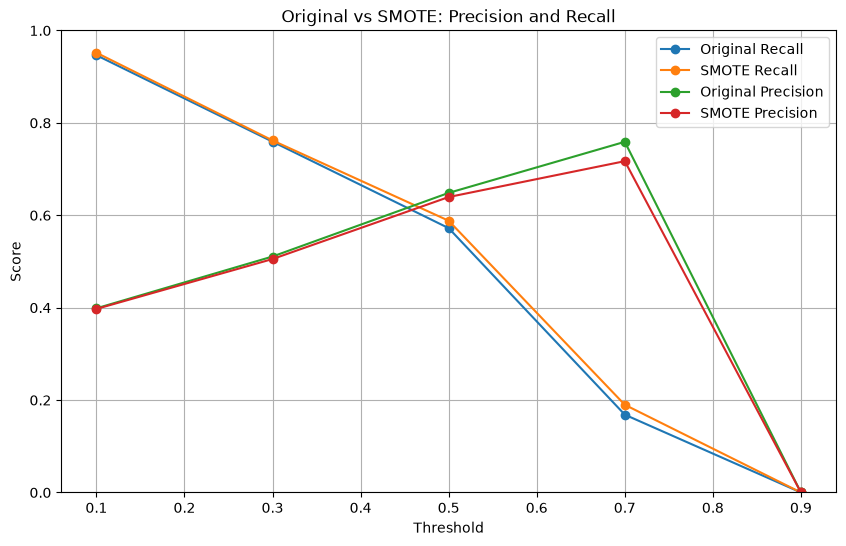

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    comparison["Threshold"],
    comparison["Original_Recall"],
    marker="o",
    label="Original Recall"
)

plt.plot(
    comparison["Threshold"],
    comparison["SMOTE_Recall"],
    marker="o",
    label="SMOTE Recall"
)

plt.plot(
    comparison["Threshold"],
    comparison["Original_Precision"],
    marker="o",
    label="Original Precision"
)

plt.plot(
    comparison["Threshold"],
    comparison["SMOTE_Precision"],
    marker="o",
    label="SMOTE Precision"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Original vs SMOTE: Precision and Recall")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

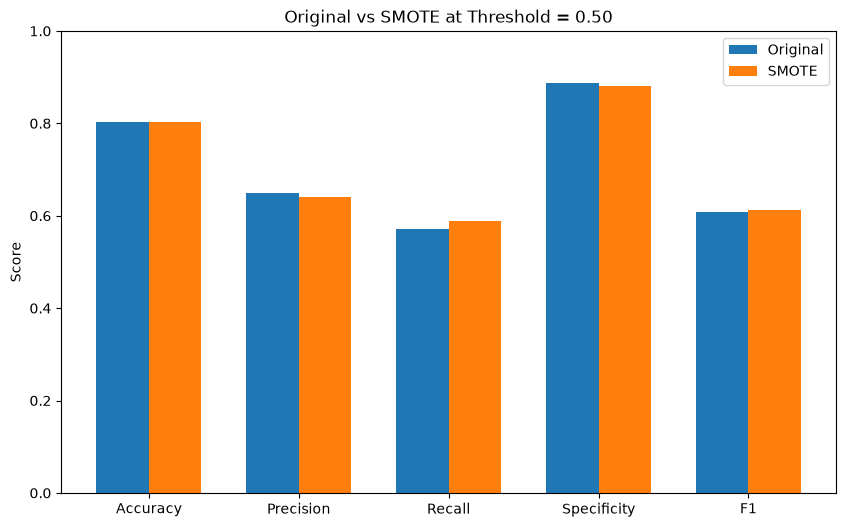

In [73]:
threshold_050 = comparison[
    comparison["Threshold"] == 0.50
]

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1"
]

original_values = [
    threshold_050["Original_Accuracy"].iloc[0],
    threshold_050["Original_Precision"].iloc[0],
    threshold_050["Original_Recall"].iloc[0],
    threshold_050["Original_Specificity"].iloc[0],
    threshold_050["Original_F1"].iloc[0]
]

smote_values = [
    threshold_050["SMOTE_Accuracy"].iloc[0],
    threshold_050["SMOTE_Precision"].iloc[0],
    threshold_050["SMOTE_Recall"].iloc[0],
    threshold_050["SMOTE_Specificity"].iloc[0],
    threshold_050["SMOTE_F1"].iloc[0]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    original_values,
    width,
    label="Original"
)

plt.bar(
    x + width/2,
    smote_values,
    width,
    label="SMOTE"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Original vs SMOTE at Threshold = 0.50")
plt.ylim(0, 1)
plt.legend()
plt.show()